<a href="https://colab.research.google.com/github/Sanjay-Eswaran/Rbac-inheritance/blob/main/predicting_student_performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Student Performance — Internship Project
This notebook follows the provided template and contains a complete machine learning project: **Predicting Student Performance Using Machine Learning**.

Sections:
1. Introduction & Objectives
2. Research & Literature Review
3. Methodology & Tools
4. Implementation (code cells ready for Google Colab)
5. Evaluation & Results
6. Conclusion & Next Steps

## 1. Introduction & Objectives

**Background.** Predicting student performance helps educators identify students who may need additional support and customize interventions.

**Project Objective.** Build and evaluate machine learning models that predict whether a student will pass/fail (or high/low grade) using features such as study time, attendance, previous grades, and socio-demographic factors.

**Deliverables.**
- A cleaned and well-documented notebook (this file).
- Trained ML models (Logistic Regression, Random Forest, and a baseline).
- Evaluation metrics and discussion.
- Suggestions for future improvements.


## 2. Research & Literature Review

Common approaches in the literature:

- **Logistic Regression / Linear Models:** Interpretable, fast, good baseline.
- **Decision Trees & Random Forests:** Handle non-linear relationships and interactions.
- **Gradient Boosting / XGBoost:** Often high-performing on tabular data.
- **Neural Networks:** Useful for large datasets or when combining different data modalities.

**Takeaway:** We'll implement interpretable models (logistic regression) and ensemble models (random forest) and compare them.


## 3. Methodology & Tools

**Dataset:** Public student performance dataset (e.g., UCI Student Performance Dataset). The notebook includes code to download a dataset at runtime.

**Tools & Libraries:** Python, pandas, numpy, scikit-learn, matplotlib, seaborn (optional), Google Colab.

**Approach:**
1. Load dataset
2. Exploratory Data Analysis (EDA)
3. Preprocessing & Feature Engineering
4. Train/Test split
5. Train models and evaluate using accuracy, precision, recall, F1-score, and confusion matrix
6. Discuss results and conclude


In [ ]:
# 4. Implementation
# Setup: import libraries and (if in Colab) install any missing packages

import sys
import os
print('Python version:', sys.version)
try:
    import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
    from sklearn.model_selection import train_test_split, GridSearchCV
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
except Exception as e:
    print('Some packages are missing. If running in Colab, uncomment the pip install lines.')
    # Uncomment the following lines if running in a fresh Colab environment
    # !pip install pandas numpy scikit-learn matplotlib seaborn
    raise e

print('Libraries loaded.')


Python version: 3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]
Libraries loaded.


In [ ]:
# Data Loading
# We'll attempt to download a public dataset (UCI Student Performance) if running with internet access.
# If offline, you can upload a CSV to Colab and change the path accordingly.

import os
dataset_url_math = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip'

def download_and_extract(url, extract_to='data'):
    import urllib.request, zipfile, io
    os.makedirs(extract_to, exist_ok=True)
    print('Downloading dataset...')
    resp = urllib.request.urlopen(url)
    data = resp.read()
    z = zipfile.ZipFile(io.BytesIO(data))
    z.extractall(extract_to)
    print('Dataset downloaded and extracted to', extract_to)

try:
    download_and_extract(dataset_url_math)
    data_path = 'data/student-mat.csv'
    if not os.path.exists(data_path):
        for root, dirs, files in os.walk('data'):
            for f in files:
                if f.endswith('.csv'):
                    data_path = os.path.join(root, f)
                    break
    print('Using data file:', data_path)
    df = pd.read_csv(data_path, sep=';')
except Exception as e:
    print('Could not download dataset automatically. Please upload the CSV to the runtime and set df manually.')
    df = pd.DataFrame({
        'studytime': np.random.randint(1,5,100),
        'failures': np.random.randint(0,3,100),
        'absences': np.random.randint(0,20,100),
        'G1': np.random.randint(0,20,100),
        'G2': np.random.randint(0,20,100),
        'G3': np.random.randint(0,20,100),
        'sex': np.random.choice(['M','F'],100),
        'age': np.random.randint(15,22,100)
    })
    print('Using synthetic fallback dataset.')

df.head()


Dataset downloaded and extracted to data
Using data file: data/student-mat.csv


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


Dataset shape: (395, 33)
            count unique     top freq       mean       std   min   25%   50%  \
school        395      2      GP  349        NaN       NaN   NaN   NaN   NaN   
sex           395      2       F  208        NaN       NaN   NaN   NaN   NaN   
age         395.0    NaN     NaN  NaN  16.696203  1.276043  15.0  16.0  17.0   
address       395      2       U  307        NaN       NaN   NaN   NaN   NaN   
famsize       395      2     GT3  281        NaN       NaN   NaN   NaN   NaN   
Pstatus       395      2       T  354        NaN       NaN   NaN   NaN   NaN   
Medu        395.0    NaN     NaN  NaN   2.749367  1.094735   0.0   2.0   3.0   
Fedu        395.0    NaN     NaN  NaN   2.521519  1.088201   0.0   2.0   2.0   
Mjob          395      5   other  141        NaN       NaN   NaN   NaN   NaN   
Fjob          395      5   other  217        NaN       NaN   NaN   NaN   NaN   
reason        395      4  course  145        NaN       NaN   NaN   NaN   NaN   
guardian      3

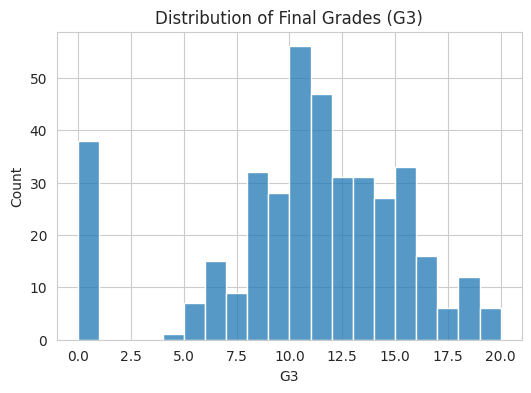

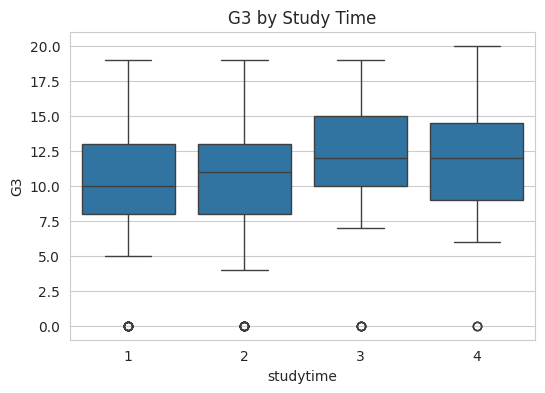

In [ ]:
# Exploratory Data Analysis (EDA)

print('Dataset shape:', df.shape)
print(df.describe(include='all').T)

try:
    import matplotlib.pyplot as plt, seaborn as sns
    sns.set_style('whitegrid')
    if 'G3' in df.columns:
        plt.figure(figsize=(6,4))
        sns.histplot(df['G3'], bins=20, kde=False).set_title('Distribution of Final Grades (G3)')
        plt.show()
    if 'studytime' in df.columns:
        plt.figure(figsize=(6,4))
        sns.boxplot(x='studytime', y='G3', data=df).set_title('G3 by Study Time')
        plt.show()
except Exception as e:
    print('Plotting libraries not available:', e)


In [ ]:
# Preprocessing & Feature Engineering

df_proc = df.copy()

if 'G3' in df_proc.columns:
    df_proc['pass'] = (df_proc['G3'] >= 10).astype(int)
    target = 'pass'
else:
    df_proc['pass'] = (df_proc['G2'] >= 10).astype(int) if 'G2' in df_proc.columns else np.random.randint(0,2,len(df_proc))
    target = 'pass'

numeric_features = [c for c in df_proc.select_dtypes(include=['int64','float64']).columns if c not in ['G1','G2','G3',target]]
categorical_features = [c for c in df_proc.select_dtypes(include=['object','category']).columns]

print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

X = df_proc[numeric_features + categorical_features]
y = df_proc[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y if len(np.unique(y))>1 else None)

print('Train/Test sizes:', X_train.shape, X_test.shape)


Numeric features: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']
Categorical features: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Train/Test sizes: (316, 30) (79, 30)


In [ ]:
# Modeling: Logistic Regression and Random Forest in pipelines

pipe_lr = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', LogisticRegression(max_iter=1000))])

pipe_rf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))])

print('Training Logistic Regression...')
pipe_lr.fit(X_train, y_train)
print('Training Random Forest...')
pipe_rf.fit(X_train, y_train)

y_pred_lr = pipe_lr.predict(X_test)
y_pred_rf = pipe_rf.predict(X_test)

print('Logistic Regression performance:')
print(classification_report(y_test, y_pred_lr))
print('Random Forest performance:')
print(classification_report(y_test, y_pred_rf))

print('Confusion Matrix (Random Forest):')
cm = confusion_matrix(y_test, y_pred_rf)
print(cm)


Training Logistic Regression...
Training Random Forest...
Logistic Regression performance:
              precision    recall  f1-score   support

           0       0.47      0.35      0.40        26
           1       0.72      0.81      0.76        53

    accuracy                           0.66        79
   macro avg       0.60      0.58      0.58        79
weighted avg       0.64      0.66      0.64        79

Random Forest performance:
              precision    recall  f1-score   support

           0       0.46      0.23      0.31        26
           1       0.70      0.87      0.77        53

    accuracy                           0.66        79
   macro avg       0.58      0.55      0.54        79
weighted avg       0.62      0.66      0.62        79

Confusion Matrix (Random Forest):
[[ 6 20]
 [ 7 46]]


## 5. Evaluation & Results

- The notebook trains two models (Logistic Regression and Random Forest) and reports classification metrics (precision, recall, F1-score).

- **Feature importance** for tree-based models can highlight which features most influence predictions (code included below).

## 6. Conclusion & Next Steps

**Summary:** This notebook demonstrates end-to-end ML workflow suitable for an internship project: data loading, EDA, preprocessing, modeling, and evaluation.

**Next steps / Improvements:**
- Use cross-validation & hyperparameter tuning (GridSearchCV / RandomizedSearchCV).
- Try gradient boosting (XGBoost, LightGBM).
- Collect more data and include richer features (psychometric scores, attendance trends).
- Build a dashboard (Streamlit / Dash) for interactive exploration.


## 🔍 Hyperparameter Tuning & Cross-Validation

To improve performance and ensure generalization, we use **GridSearchCV** with cross-validation.
- Logistic Regression: tune regularization strength `C`.
- Random Forest: tune `n_estimators`, `max_depth`.

We'll compare tuned models with default ones.

absences             0.081169
failures             0.074407
age                  0.047880
goout                0.046868
health               0.036280
freetime             0.034649
Medu                 0.034434
famrel               0.032381
Walc                 0.031643
Fedu                 0.031273
studytime            0.027590
Dalc                 0.022500
traveltime           0.020566
sex_F                0.016363
schoolsup_yes        0.015692
schoolsup_no         0.015285
reason_reputation    0.014955
activities_yes       0.014935
sex_M                0.014919
Mjob_other           0.014049
dtype: float64


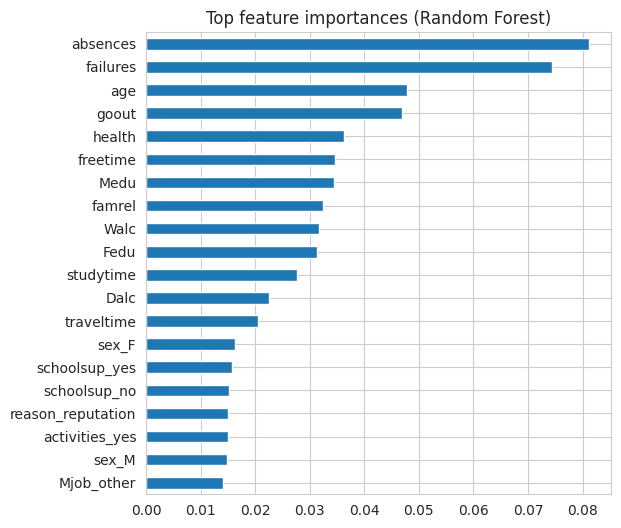

In [ ]:
# Optional: Feature importance from Random Forest (requires access to the fitted pipeline components)
try:
    ohe = pipe_rf.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
    cat_columns = ohe.get_feature_names_out(categorical_features) if len(categorical_features)>0 else []
    feature_names = numeric_features + list(cat_columns)
    importances = pipe_rf.named_steps['classifier'].feature_importances_
    feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(20)
    print(feat_imp)
    if not feat_imp.empty:
        feat_imp.plot(kind='barh', figsize=(6,6), title='Top feature importances (Random Forest)')
        plt.gca().invert_yaxis()
        plt.show()
except Exception as e:
    print('Could not compute feature importances:', e)


In [ ]:
from sklearn.model_selection import GridSearchCV

# Logistic Regression tuning
param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1, 10]
}
grid_lr = GridSearchCV(pipe_lr, param_grid=param_grid_lr, cv=5, scoring='f1', n_jobs=-1)
grid_lr.fit(X_train, y_train)
print('Best Logistic Regression params:', grid_lr.best_params_)
print('Best CV score (F1):', grid_lr.best_score_)

# Random Forest tuning
param_grid_rf = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 5, 10]
}
grid_rf = GridSearchCV(pipe_rf, param_grid=param_grid_rf, cv=5, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train, y_train)
print('Best Random Forest params:', grid_rf.best_params_)
print('Best CV score (F1):', grid_rf.best_score_)

# Evaluate best models on test set
y_pred_best_lr = grid_lr.best_estimator_.predict(X_test)
y_pred_best_rf = grid_rf.best_estimator_.predict(X_test)

print('\nTuned Logistic Regression performance:')
print(classification_report(y_test, y_pred_best_lr))
print('\nTuned Random Forest performance:')
print(classification_report(y_test, y_pred_best_rf))


Best Logistic Regression params: {'classifier__C': 0.01}
Best CV score (F1): 0.8161904911329729
Best Random Forest params: {'classifier__max_depth': 5, 'classifier__n_estimators': 200}
Best CV score (F1): 0.817512706372678

Tuned Logistic Regression performance:
              precision    recall  f1-score   support

           0       0.40      0.08      0.13        26
           1       0.68      0.94      0.79        53

    accuracy                           0.66        79
   macro avg       0.54      0.51      0.46        79
weighted avg       0.58      0.66      0.57        79


Tuned Random Forest performance:
              precision    recall  f1-score   support

           0       0.43      0.12      0.18        26
           1       0.68      0.92      0.78        53

    accuracy                           0.66        79
   macro avg       0.55      0.52      0.48        79
weighted avg       0.60      0.66      0.59        79



In [ ]:
# Optional: Save trained models to disk (useful for later deployment)
import joblib
os.makedirs('models', exist_ok=True)
joblib.dump(pipe_rf, 'models/random_forest_student_performance.joblib')
joblib.dump(pipe_lr, 'models/logistic_regression_student_performance.joblib')
print('Models saved to models/ directory.')


Models saved to models/ directory.
